# Overlap with transposable elements

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
cd = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/"
mpra_alus = pl.read_csv(cd+"results/MPRA_analysis/CMPRA5/labeled_data_promoteroa_alus_OA.tsv", separator="\t")
mpra_repeats = pl.read_csv(cd+"results/MPRA_analysis/CMPRA5/labeled_data_promoteroa_repeats_OA.tsv", separator="\t")

In [72]:
mpra_repeats = mpra_repeats.filter(pl.col("promoter").is_null().not_()).with_columns(
	# Get unique, sorted OE_repeats
	pl.col("OE_repeats").str.split(",").list.unique().list.sort().list.join(",").alias("OE_repeats"),
	# Count occurrences of each OE_repeat
	pl.len().over("OE_repeats").alias("count")
)

In [ ]:
mpra_alus = mpra_alus.with_columns(
	pl.when((pl.col("promoter_alu") == "yes") & (pl.col("OE_alu") == "no")).then(pl.lit("alu in promoter"))
	.when((pl.col("OE_alu") == "yes") & (pl.col("promoter_alu") == "no")).then(pl.lit("alu in CRE"))
	.when((pl.col("OE_alu") == "yes") & (pl.col("promoter_alu") == "yes")).then(pl.lit("alu in promoter and CRE"))
	.otherwise(pl.lit("no alu")).alias("alu_location")
)

<Axes: xlabel='z_score', ylabel='Count'>

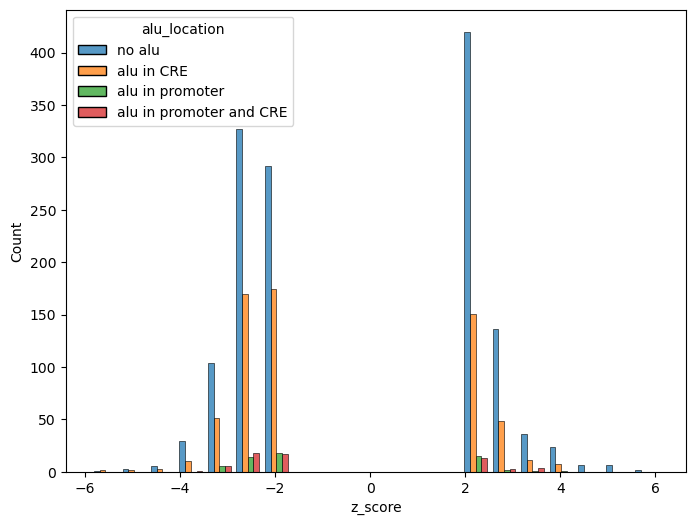

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
sns.histplot(data=mpra_alus.filter(pl.col("effect")!="no effect").to_pandas(), x="z_score", hue="alu_location", bins=20, multiple="dodge", shrink=.8)

<Axes: xlabel='z_score', ylabel='Count'>

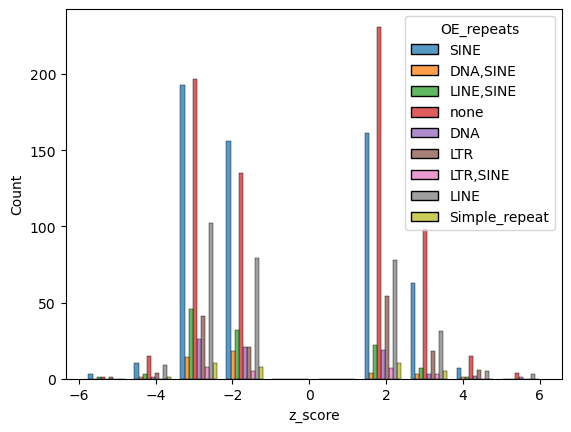

In [59]:
sns.histplot(data=mpra_repeats.filter(pl.col("effect")!="no effect")
			 .filter(pl.col("count")> 500).to_pandas(), x="z_score", hue="OE_repeats", bins=10, multiple="dodge", shrink=.8)

In [60]:
mpra_repeats.select(pl.col("OE_repeats"), pl.len().over("OE_repeats").alias("count")).unique().sort("count", descending=True)

OE_repeats,count
str,u32
"""none""",19831
"""SINE""",17317
"""LINE""",7477
"""LTR""",3641
"""LINE,SINE""",2494
…,…
"""LINE,Simple_repeat,rRNA""",1
"""DNA,LTR,Simple_repeat""",1
"""LTR,Satellite""",1


In [64]:
mpra_repeats.filter(pl.col("effect")!="no effect") \
			.select("effect",pl.col("OE_repeats"), pl.len().over("OE_repeats","effect").alias("count")/pl.len().over("effect"))

effect,OE_repeats,count
str,str,f64
"""downregulating""","""SINE""",0.289369
"""upregulating""","""DNA,SINE""",0.009029
"""downregulating""","""LINE,SINE""",0.065548
"""upregulating""","""none""",0.392777
"""upregulating""","""LINE,SINE""",0.03386
…,…,…
"""upregulating""","""none""",0.392777
"""downregulating""","""SINE,Simple_repeat""",0.015188
"""upregulating""","""SINE""",0.260722


<Axes: xlabel='fraction', ylabel='OE_repeats'>

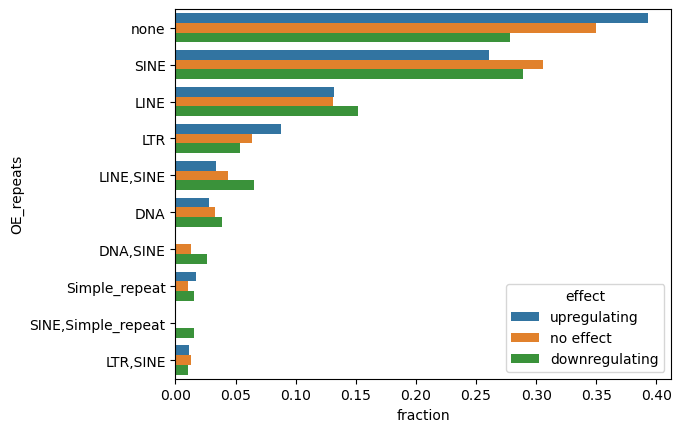

In [67]:
sns.barplot(mpra_repeats
			#.filter(pl.col("effect")!="no effect")
			.select("effect",pl.col("OE_repeats"), pl.len().over("OE_repeats","effect").alias("fraction")/pl.len().over("effect")).unique().sort("fraction", descending=True)
			.filter(pl.col("fraction")>0.01).to_pandas(),
			x="fraction", y="OE_repeats", orient='h', hue="effect")

In [80]:
# Now ungrouping different classes

mpra_repeats_exploded = mpra_repeats.with_columns(
	pl.col("OE_repeats").str.split(",").alias("OE_repeats_exploded")
).explode("OE_repeats_exploded")

In [98]:
mpra_repeats_exploded.select(
		   # Making sure to count unique interactions for fraction, since we can now have the same interaction in the dataset multiple times
		   (pl.len().over("OE_repeats_exploded","effect")/(pl.col("left_bin")+pl.col("right_bin")).n_unique().over("effect")).alias("frac")).unique()

frac
f64
0.180587
0.423661
0.087096
0.002102
0.392777
…
0.000329
0.000128
0.080735


<Axes: xlabel='fraction', ylabel='OE_repeats_exploded'>

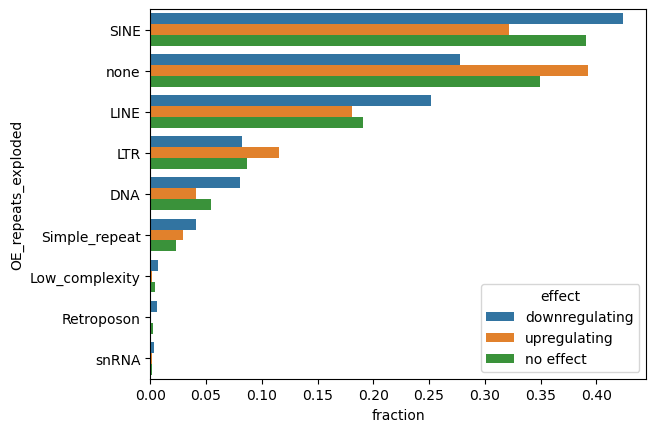

In [103]:
sns.barplot(mpra_repeats_exploded
			#.filter(pl.col("effect")!="no effect")
			.select("effect",pl.col("OE_repeats_exploded"), 
		   # Making sure to count unique interactions for fraction, since we can now have the same interaction in the dataset multiple times
		   pl.len().over("OE_repeats_exploded","effect").alias("fraction")/(pl.col("left_bin")+pl.col("right_bin")).n_unique().over("effect")).unique()
		   .sort("fraction", descending=True)
			.filter(pl.col("fraction")>0.001).to_pandas(),
			x="fraction", y="OE_repeats_exploded", orient='h', hue="effect")